# HeatGov AI - 03. Feature diagnostics

Does the feature table built in Step 3 contain enough signal to train a model in
Step 4? This notebook answers that before any model is fitted.

It reads only `data/processed/zone_features.parquet` and the matching GeoJSON.
No API calls, no network.

**The bar we set ourselves:** if XGBoost is going to work at Step 4, we should
see `|r| > 0.3` for at least 3 features.

## 1. Load

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "backend"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config

df = pd.read_parquet(PROJECT_ROOT / "data/processed/zone_features.parquet")
gdf = gpd.read_file(PROJECT_ROOT / "data/processed/zone_features.geojson")

FEATURES = [f for f in config.FEATURES_FULL if f in df.columns]
MISSING = [f for f in config.FEATURES_FULL if f not in df.columns]
LABEL = config.LABEL_COLUMN

print(f"tracts   : {len(df)}")
print(f"features : {len(FEATURES)}")
if MISSING:
    print(f"absent   : {MISSING}")
print(f"label    : {LABEL}  range {df[LABEL].min():.1f} - {df[LABEL].max():.1f}")
df.head()

tracts   : 94
features : 11
absent   : ['tree_canopy_pct']
label    : CIscoreP  range 31.2 - 99.8


,tract_fips,temp_max_15h,temp_max_22h,exceedance_hours_30C,persistence_max_hours,peak_hour_mode,elevation_m,distance_to_coast_km,pop_over_65_pct,median_income,pop_density,impervious_surface_pct,approx_location,n_tiles,tract_area_km2,CIscoreP,pollution_burden_pctl,population_char_pctl
0,06037181300,30.547000,19.197800,86.995012,9.9975,3.0,157.753874,28.877070,18.1,110508.0,2823.039246,47.617932,Los Angeles,101,1.437812,57.135653,83.970131,37.039839
1,06037185203,29.833690,18.804450,62.038542,10.0324,16.0,140.263085,26.463215,8.6,49698.0,6547.230195,62.052411,Los Angeles,55,0.544658,93.406455,89.819540,86.787695
2,06037185204,30.008500,19.094250,70.813413,10.0558,16.0,139.124836,27.298424,23.9,86971.0,1986.818307,26.457494,Los Angeles,75,0.966873,46.772567,53.839452,39.838628
3,06037185310,29.801925,19.106010,72.304462,10.0573,3.0,129.065640,26.921925,12.5,64671.0,7418.932456,68.913832,Los Angeles,34,0.422028,93.545134,91.860610,84.417549
4,06037185320,29.805720,19.002545,68.259619,10.0708,16.0,126.364402,26.576775,10.7,42202.0,5026.330747,76.466994,Los Angeles,58,0.595066,98.777105,98.481643,89.409985


## 2. Distribution of every feature

What we are looking for: spread. A feature whose histogram is a single spike
carries no information, however scientifically meaningful it sounds. Three of
the four `env_params` features from the original specification were dropped in
Step 2 for exactly this reason.

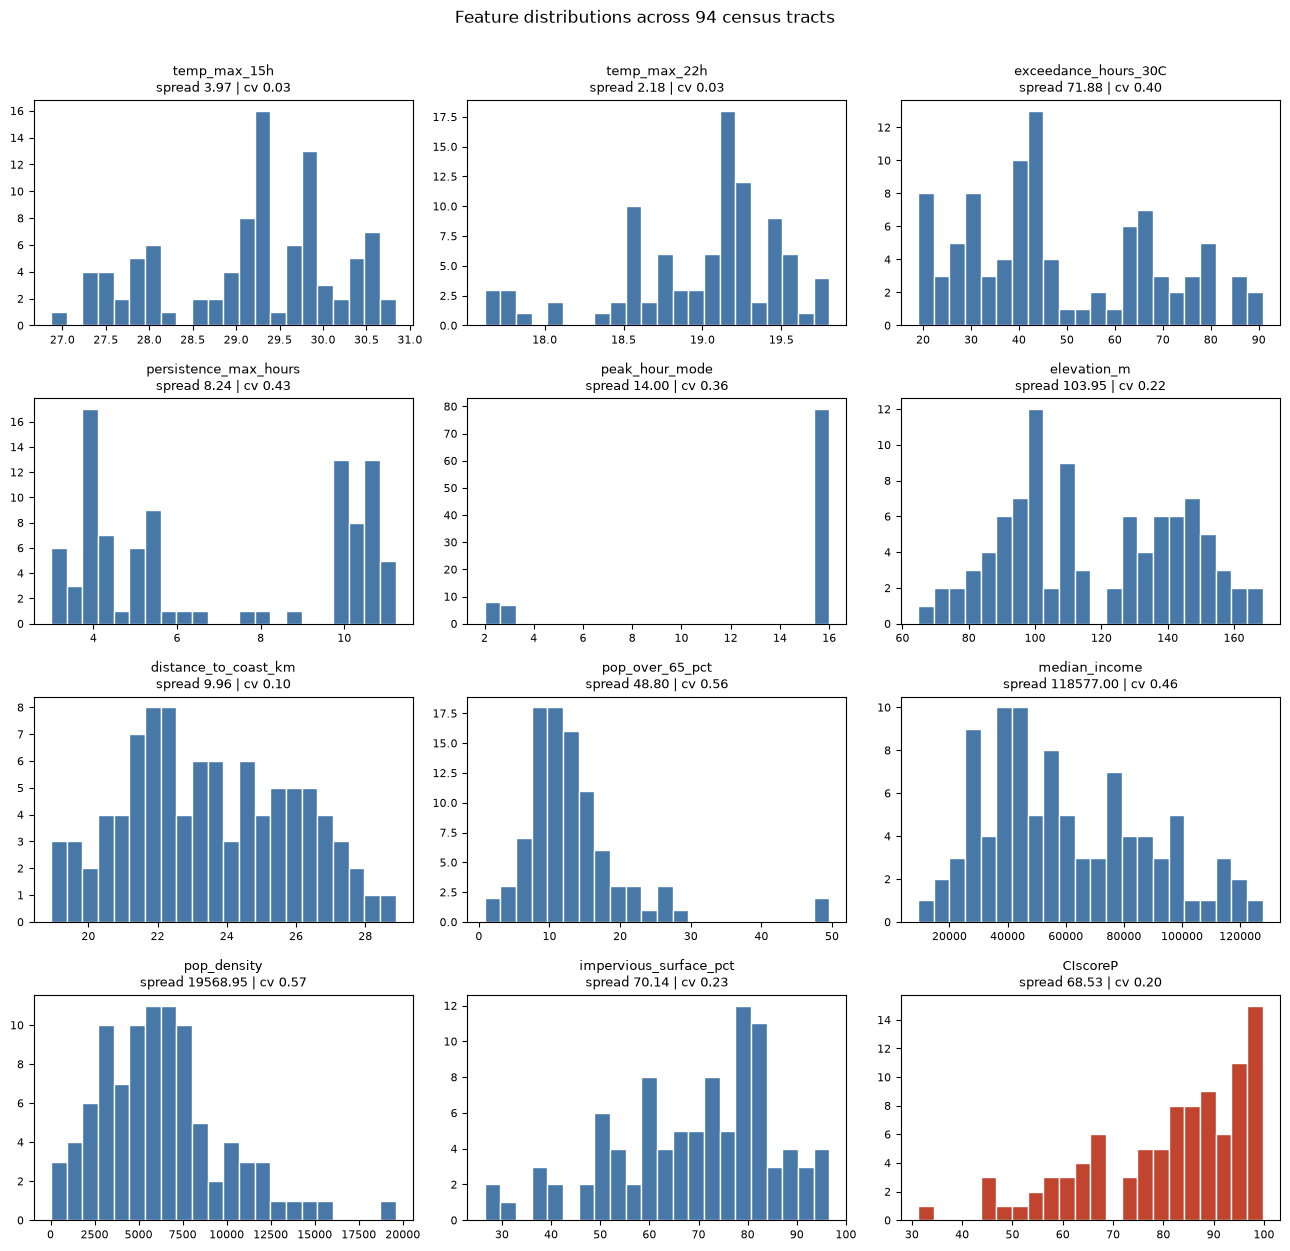

In [2]:
cols = 3
rows = int(np.ceil((len(FEATURES) + 1) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(13, 3.1 * rows))
axes = axes.ravel()

for ax, name in zip(axes, FEATURES + [LABEL]):
    series = df[name].dropna()
    is_label = name == LABEL
    ax.hist(series, bins=22, color="#c1442e" if is_label else "#4878a8",
            edgecolor="white")
    cv = series.std() / abs(series.mean()) if series.mean() else np.nan
    ax.set_title(f"{name}\nspread {series.max() - series.min():.2f} | cv {cv:.2f}",
                 fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[len(FEATURES) + 1:]:
    ax.axis("off")

fig.suptitle(f"Feature distributions across {len(df)} census tracts", y=1.005)
fig.tight_layout()
plt.show()

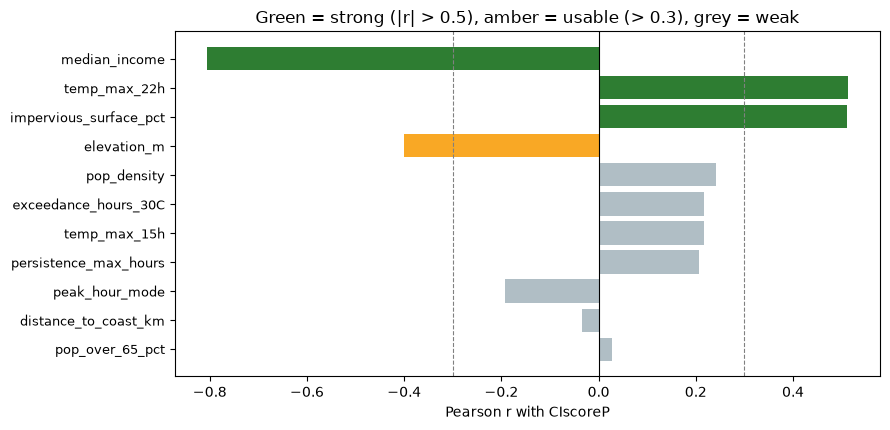

4 feature(s) exceed |r| > 0.3
BAR: if XGBoost is going to work at Step 4, we should see |r| > 0.3 for at least 3 features.
PASS


In [3]:
corr = (
    df[FEATURES + [LABEL]]
    .corr(numeric_only=True)[LABEL]
    .drop(LABEL)
    .sort_values(key=abs, ascending=False)
)

colors = ["#2e7d32" if abs(v) > 0.5 else "#f9a825" if abs(v) > 0.3 else "#b0bec5"
          for v in corr]

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(range(len(corr)), corr.values, color=colors)
ax.set_yticks(range(len(corr)), corr.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
for threshold in (-0.3, 0.3):
    ax.axvline(threshold, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"Pearson r with {LABEL}")
ax.set_title("Green = strong (|r| > 0.5), amber = usable (> 0.3), grey = weak")
fig.tight_layout()
plt.show()

strong = int((corr.abs() > 0.3).sum())
print(f"{strong} feature(s) exceed |r| > 0.3")
print("BAR: if XGBoost is going to work at Step 4, we should see |r| > 0.3 for "
      "at least 3 features.")
print("PASS" if strong >= 3 else "FAIL - expect a weak model, and say so honestly.")

## 4. The geography check

Step 2 found that heat in Central Los Angeles is governed by distance from the
ocean, not by land cover: the northern band, which has the most tree canopy, was
the hottest. If `elevation_m` or `distance_to_coast_km` ranks at the top here,
that confirms the finding and is a genuine scientific result rather than a
modelling artefact.

In [4]:
GEOGRAPHIC = [c for c in ("elevation_m", "distance_to_coast_km") if c in corr.index]
top = corr.abs().idxmax()

print(f"strongest predictor overall : {top}  (r = {corr[top]:+.3f})")
for name in GEOGRAPHIC:
    print(f"  {name:<22} r = {corr[name]:+.3f}")

if top in GEOGRAPHIC:
    print()
    print("CONFIRMED: a geographic feature dominates. Maritime influence, not land")
    print("cover, drives the pattern at this scale. This is the Step 2 finding "
          "reproduced at tract level.")
else:
    print()
    print(f"Geography does not dominate; {top} does.")

if {"elevation_m", "distance_to_coast_km"} <= set(FEATURES):
    collinear = df["elevation_m"].corr(df["distance_to_coast_km"])
    print()
    print(f"COLLINEARITY elevation_m vs distance_to_coast_km: r = {collinear:+.3f}")
    print("above 0.8 -> drop one at Step 4" if abs(collinear) > 0.8
          else "below 0.8 -> both can stay")

strongest predictor overall : median_income  (r = -0.806)
  elevation_m            r = -0.400
  distance_to_coast_km   r = -0.035

Geography does not dominate; median_income does.

COLLINEARITY elevation_m vs distance_to_coast_km: r = +0.661
below 0.8 -> both can stay


## 5. The five strongest features, plotted against the label

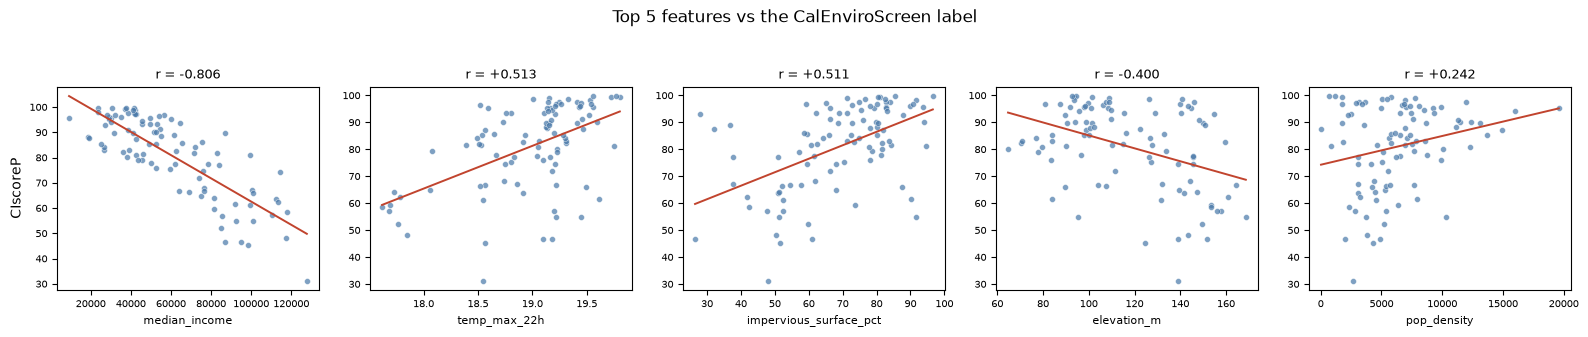

In [5]:
top5 = corr.abs().nlargest(5).index
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))

for ax, name in zip(axes, top5):
    ax.scatter(df[name], df[LABEL], s=18, alpha=0.7, color="#4878a8",
               edgecolor="white", linewidth=0.4)
    sub = df[[name, LABEL]].dropna()
    if len(sub) > 2:
        slope, intercept = np.polyfit(sub[name], sub[LABEL], 1)
        xs = np.linspace(sub[name].min(), sub[name].max(), 50)
        ax.plot(xs, slope * xs + intercept, color="#c1442e", linewidth=1.4)
    ax.set_xlabel(name, fontsize=8)
    ax.set_title(f"r = {corr[name]:+.3f}", fontsize=9)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel(LABEL)
fig.suptitle("Top 5 features vs the CalEnviroScreen label", y=1.04)
fig.tight_layout()
plt.show()

## 6. Label leakage, measured rather than assumed

CalEnviroScreen's composite score is half "Pollution Burden" and half
"Population Characteristics", and that second half already contains poverty,
unemployment and housing burden. Feeding median income back in as a predictor
means partly predicting the label from its own ingredients.

The numbers below quantify how much. This is why Step 4 trains two models.

In [6]:
for half in ("pollution_burden_pctl", "population_char_pctl"):
    if half in df.columns:
        r = df[half].corr(df[LABEL])
        print(f"{half:<24} vs label: r = {r:+.3f}  ({r*r*100:.0f}% of variance)")

print()
if "median_income" in df.columns and "population_char_pctl" in df.columns:
    r = df["median_income"].corr(df["population_char_pctl"])
    print(f"median_income vs population_char_pctl: r = {r:+.3f}")
    print("Income is close to a mirror of the label's own socio-economic half.")

print()
fg = [f for f in config.FEATURES_FORTYGUARD if f in df.columns]
socio = [f for f in config.FEATURES_SOCIO if f in df.columns]
print(f"Model A - FortyGuard + geography ({len(fg)} features): "
      f"best |r| = {corr[fg].abs().max():.3f}")
print(f"Model B - full ({len(FEATURES)} features): "
      f"best |r| = {corr.abs().max():.3f}")
print()
print("The gap between the two is the honest measure of what FortyGuard data "
      "contributes on its own.")

pollution_burden_pctl    vs label: r = +0.598  (36% of variance)
population_char_pctl     vs label: r = +0.875  (77% of variance)

median_income vs population_char_pctl: r = -0.842
Income is close to a mirror of the label's own socio-economic half.

Model A - FortyGuard + geography (7 features): best |r| = 0.513
Model B - full (11 features): best |r| = 0.806

The gap between the two is the honest measure of what FortyGuard data contributes on its own.


## 7. Sanity map

Do the label and the night-time heat layer look spatially plausible, or has a
join gone wrong? A scrambled join shows up immediately as spatial noise.

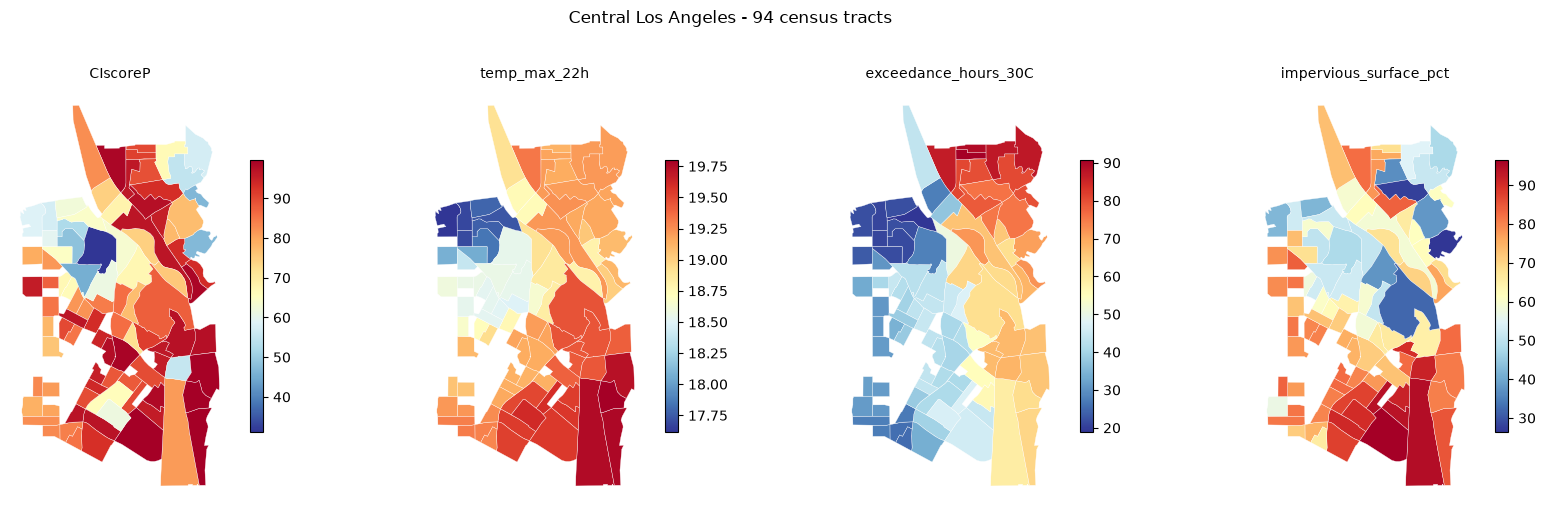

In [7]:
panels = [LABEL, "temp_max_22h", "exceedance_hours_30C", "impervious_surface_pct"]
panels = [p for p in panels if p in gdf.columns]

fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 5))
axes = np.atleast_1d(axes)

for ax, name in zip(axes, panels):
    gdf.plot(column=name, ax=ax, cmap="RdYlBu_r", legend=True,
             edgecolor="white", linewidth=0.25,
             legend_kwds={"shrink": 0.65})
    ax.set_title(name, fontsize=10)
    ax.set_axis_off()

fig.suptitle(f"Central Los Angeles - {len(gdf)} census tracts", y=1.02)
fig.tight_layout()
plt.show()

## 8. Full correlation matrix

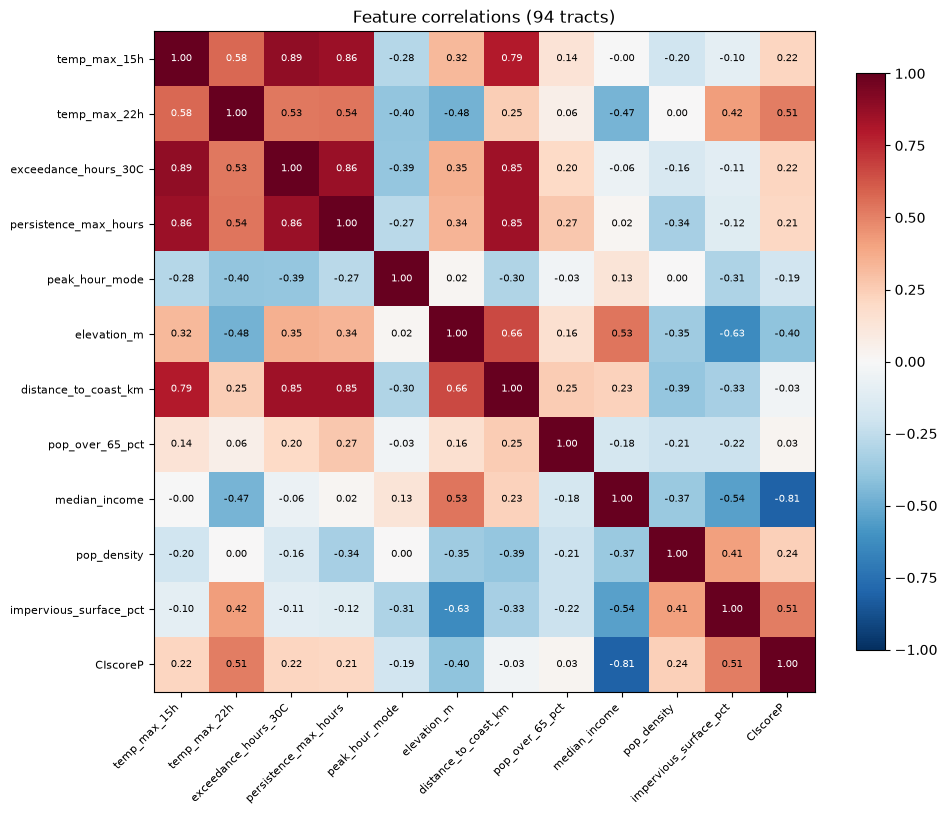

Feature pairs with |r| > 0.8 (redundant, drop one at Step 4):
  temp_max_15h <-> exceedance_hours_30C: +0.886
  temp_max_15h <-> persistence_max_hours: +0.857
  exceedance_hours_30C <-> persistence_max_hours: +0.861
  exceedance_hours_30C <-> distance_to_coast_km: +0.851
  persistence_max_hours <-> distance_to_coast_km: +0.846


In [8]:
columns = FEATURES + [LABEL]
matrix = df[columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8.5))
image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(columns)), columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(columns)), columns, fontsize=8)

for i in range(len(columns)):
    for j in range(len(columns)):
        value = matrix.iat[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(value) > 0.55 else "black")

ax.set_title(f"Feature correlations ({len(df)} tracts)")
fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

redundant = [
    (a, b, matrix.loc[a, b])
    for i, a in enumerate(FEATURES) for b in FEATURES[i + 1:]
    if abs(matrix.loc[a, b]) > 0.8
]
print("Feature pairs with |r| > 0.8 (redundant, drop one at Step 4):")
for a, b, r in redundant or []:
    print(f"  {a} <-> {b}: {r:+.3f}")
if not redundant:
    print("  none")

## 9. Verdict

In [9]:
print("=" * 70)
print("STEP 3 DIAGNOSTIC VERDICT")
print("=" * 70)
print(f"tracts                       : {len(df)}")
print(f"features                     : {len(FEATURES)}" +
      (f"  (absent: {MISSING})" if MISSING else ""))
print(f"label NaN                    : {df[LABEL].isna().sum()}")
print(f"features with |r| > 0.3      : {strong}")
print(f"strongest FortyGuard feature : {corr[fg].abs().idxmax()} "
      f"(r = {corr[fg[int(np.argmax(corr[fg].abs()))]]:+.3f})")

dead = [f for f in FEATURES if df[f].std() < 1e-6]
print(f"dead features (no variance)  : {dead or 'none'}")

ready = strong >= 3 and df[LABEL].isna().sum() == 0 and not dead
print()
print("READY FOR STEP 4" if ready else "NOT READY - address the points above")

STEP 3 DIAGNOSTIC VERDICT
tracts                       : 94
features                     : 11  (absent: ['tree_canopy_pct'])
label NaN                    : 0
features with |r| > 0.3      : 4
strongest FortyGuard feature : temp_max_22h (r = +0.513)
dead features (no variance)  : none

READY FOR STEP 4
